In [1]:
%matplotlib inline

import os, random, time, sys, warnings, copy
from timeit import default_timer as timer
from datetime import timedelta
from datetime import datetime
import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy import signal
import pandas as pd
import bct
from tqdm import tqdm

import neurogym as ngym
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from src.neural_network import RNN, run_training, run_testing
from src.utils import normalize_x, build_reg_ken, compute_rlfp, fix_labels, get_weight_masks, get_weight_masks_schaefer, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
import seaborn as sns
from src.plotting import my_reg_plot, plot_activity, plot_iodata

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'
# task = 'MultiSensoryIntegration-v0'
# task = 'ContextDecisionMaking-v0'
dt = 100
batch_size = 32
decision = 300
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 5

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 25
n_epochs = 30000
lr = 0.001

# regularization parameters
# kernel_type = 'sa_axis'
kernel_type = 'euclidean'
# kernel_type = None
reg_type = 'l2'
reg_weight = 0.002
mask_weights = True

print(seq_len, reg_weight)

120 0.002


In [4]:
if task == 'ContextDecisionMaking-v0':
    timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
else:
    timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}
# env_kwargs = {'dt': dt}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'kernel_type': kernel_type, 'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs
}

3 3
(120, 32, 3) (120, 32)


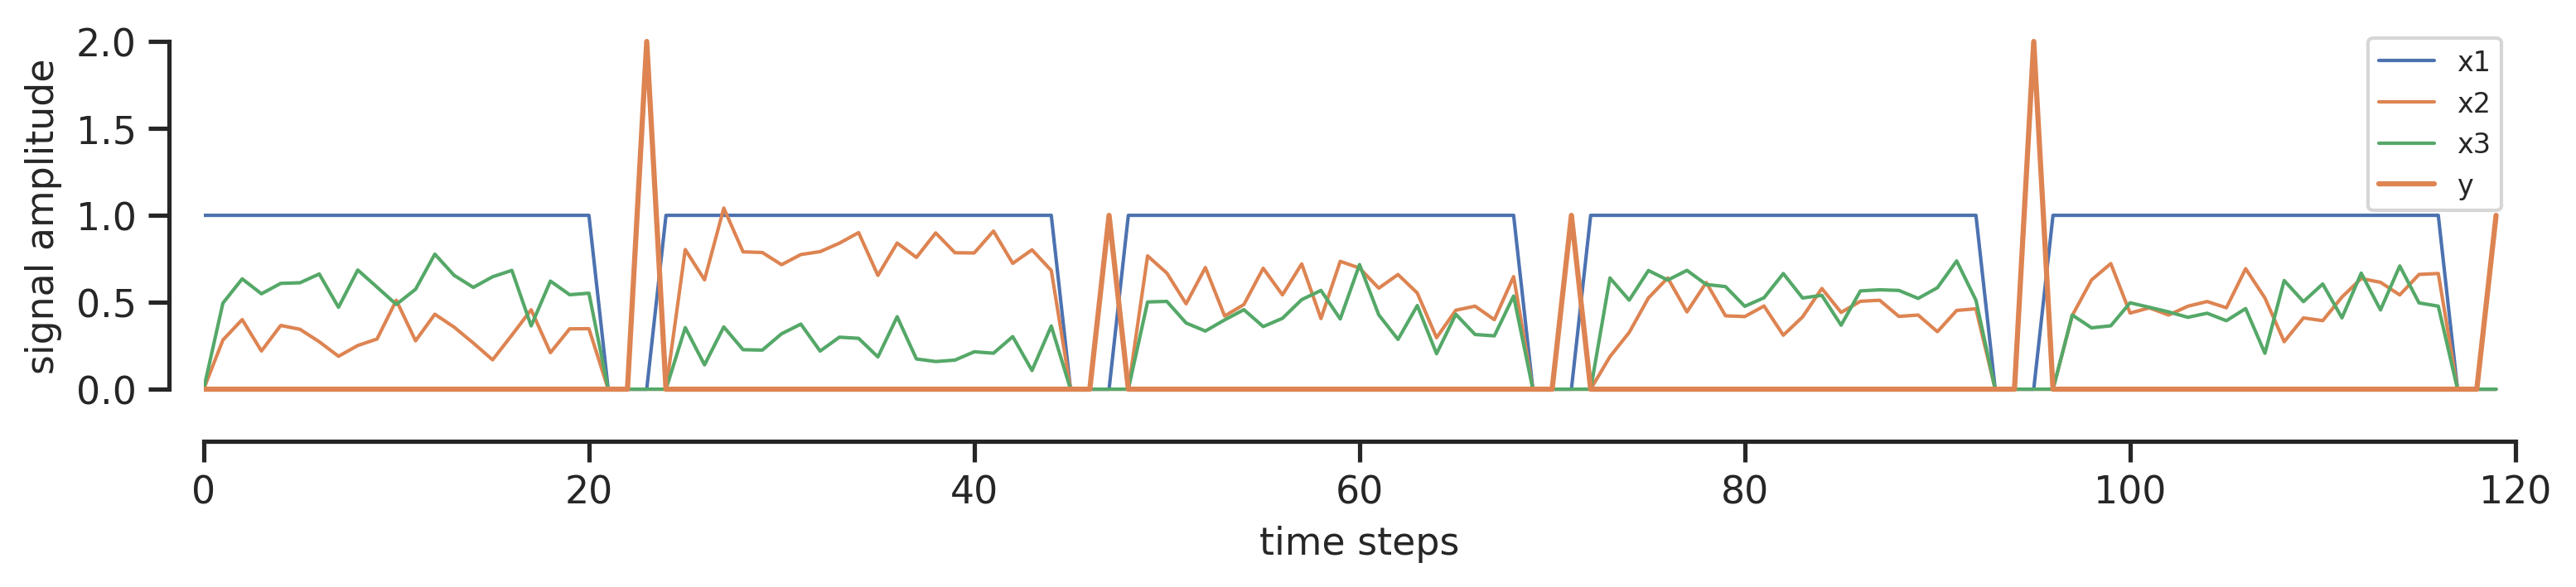

In [5]:
# Environment
# Make supervised dataset
dataset = ngym.Dataset(config['task'], env_kwargs=env_kwargs, batch_size=config['batch_size'], seq_len=config['seq_len'])
dataset.env.reset(seed=0)
input_size = dataset.env.observation_space.shape[0]
num_classes = dataset.env.action_space.n
print(input_size, num_classes)

# plot
inputs, labels = dataset()
trim = int((decision - 100) / dt)
labels = fix_labels(labels, decision=int(decision / dt), trim=trim)
print(inputs.shape, labels.shape)

# plot input/output (x/y) data
plot_iodata(
    inputs[:, 0, :], labels[:, 0],
    rc_params={'figure.dpi': 300, 'savefig.dpi': 300},
    show=True, ax_params={'xlim': [0, seq_len]}
)

Setup weight masks

In [6]:
# weight masks
centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
centroids = centroids[:hidden_size]
roi_names = list(centroids['ROI Name'])
input_system = 'Vis'
output_system = 'Default'
masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)

if mask_weights:
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io
print(n_io)

14-27


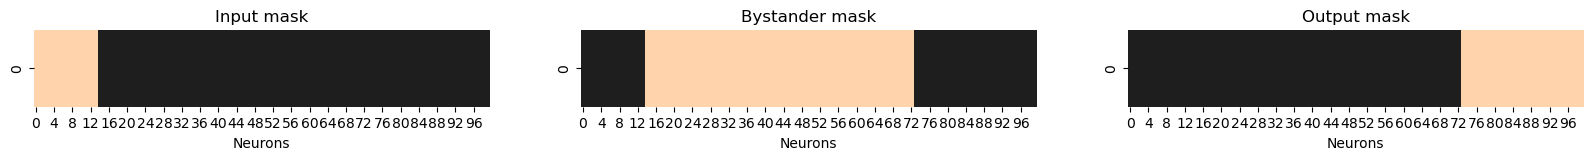

In [7]:
f, ax = plt.subplots(1, 3, figsize=(20, 1))
sns.heatmap(masks['input_weight_mask'][np.newaxis], ax=ax[0], square=False, center=0, cbar=False)
ax[0].set_title('Input mask')
ax[0].set_xlabel('Neurons')
sns.heatmap(masks['bystanders'][np.newaxis], ax=ax[1], square=False, center=0, cbar=False)
ax[1].set_title('Bystander mask')
ax[1].set_xlabel('Neurons')
sns.heatmap(masks['output_weight_mask'][np.newaxis], ax=ax[2], square=False, center=0, cbar=False)
ax[2].set_title('Output mask')
ax[2].set_xlabel('Neurons')
plt.show()

In [8]:
mask_labels = ['input_input', 'bystanders_bystanders', 'output_output',
               'input_output', 'output_input',
               'input_bystanders', 'bystanders_input',
               'output_bystanders', 'bystanders_output']
n_masks = len(mask_labels)

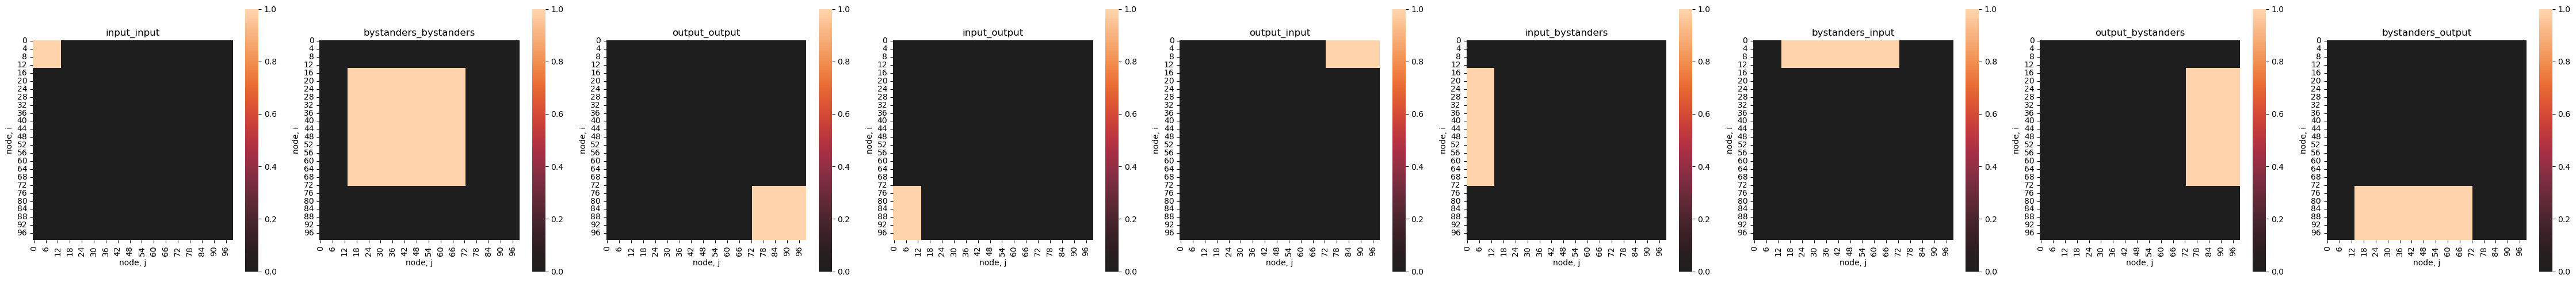

In [9]:
f, ax = plt.subplots(1, n_masks, figsize=(n_masks*5, 5))
for i, mask in enumerate(mask_labels):
    sns.heatmap(masks[mask], ax=ax[i], square=True, center=0)
    ax[i].set_title(mask)
    ax[i].set_xlabel('node, j')
    ax[i].set_ylabel('node, i')
f.tight_layout()
plt.show()

Setup regularization kernel

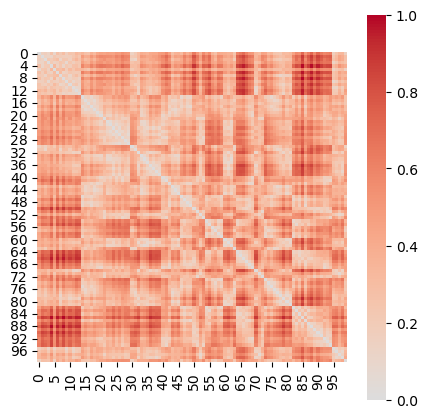

In [10]:
# setup regularization kernel
if kernel_type is None:
    # no distance penalty
    regularization_kernel = None
elif kernel_type == 'euclidean':
    # static distance matrix for regularization
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    centroids = centroids[:hidden_size]
    centroids.set_index("ROI Name", inplace=True)
    distance_matrix = distance.pdist(centroids, "euclidean")  # get euclidean distances between nodes
    distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix
    regularization_kernel = normalize_x(distance_matrix)
elif kernel_type == 'sa_axis':
    sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(hidden_size * 2)))
    sa_axis = sa_axis[:hidden_size]
    n = len(sa_axis)
    distance_matrix = np.zeros((n, n))
    for i in np.arange(n):
        for j in np.arange(n):
            distance_matrix[i, j] = sa_axis[i] - sa_axis[j]
    distance_matrix = np.abs(distance_matrix)
    regularization_kernel = normalize_x(distance_matrix)

if regularization_kernel is None:
    pass
elif regularization_kernel.ndim == 2:
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.heatmap(regularization_kernel, ax=ax, square=True, cmap='coolwarm', center=0)
    plt.show()
elif regularization_kernel.ndim == 3:
    f, ax = plt.subplots(1, 4, figsize=(20, 5))
    sns.heatmap(regularization_kernel[:, :, 0], ax=ax[0], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[0].set_title('Epoch 0')
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.33)], ax=ax[1], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[1].set_title('Epoch {0}'.format(int(n_epochs*.33)))
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.66)], ax=ax[2], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[2].set_title('Epoch {0}'.format(int(n_epochs*.66)))
    sns.heatmap(regularization_kernel[:, :, -1], ax=ax[3], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[3].set_title('Epoch {0}'.format(int(n_epochs)))
plt.show()

In [11]:
# if regularization_kernel.ndim == 2:
#     A = 1 - regularization_kernel.copy()
#     thresh = np.quantile(A, q=0.8)
#     matrix_mask = A > thresh
#     A[matrix_mask] = 1
#     A[~matrix_mask] = 0
#     _, q_stat = bct.modularity_und(A, gamma=1)
#     print(q_stat)
#
#     f, ax = plt.subplots(1, 1, figsize=(5, 5))
#     sns.heatmap(A, ax=ax, square=True, cmap='coolwarm', center=0, vmax=1)
#     plt.show()

Train model

In [12]:
run = 0
random.seed(run)
np.random.seed(run)
torch.manual_seed(run)
torch.cuda.manual_seed(run)
torch.cuda.manual_seed_all(run)

In [13]:
# setup weight masks
if mask_weights:
    input_weight_mask = masks['input_weight_mask']
    output_weight_mask = masks['output_weight_mask']
else:
    input_weight_mask = None
    output_weight_mask = None
    print(input_weight_mask, output_weight_mask)

In [14]:
# initialize the model
model = RNN(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes, type=rnn_model,
            regularization_kernel=regularization_kernel,
            input_weight_mask=input_weight_mask, output_weight_mask=output_weight_mask).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = None
# scheduler = lr_scheduler.StepLR(optimizer, step_size=int(n_epochs*0.2))
# lambda1 = lambda lr: 0.99 ** lre
# scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)
# train the model
# tra_loss, val_loss, tes_acc, model_state = run_training(dataset=dataset, model=model, optimizer=optimizer, criterion=criterion, config=config, scheduler=scheduler, return_models=True)
tra_loss, val_loss, tes_acc = run_training(dataset=dataset, model=model, optimizer=optimizer, criterion=criterion, config=config, scheduler=scheduler, return_models=False)

epoch 100 | running training loss: 0.38446 | running validation loss: 0.34569 | test accuracy: 0.00%
epoch 200 | running training loss: 0.23823 | running validation loss: 0.21516 | test accuracy: 0.00%
epoch 300 | running training loss: 0.23049 | running validation loss: 0.21358 | test accuracy: 0.00%
epoch 400 | running training loss: 0.22475 | running validation loss: 0.21221 | test accuracy: 0.00%
epoch 500 | running training loss: 0.20863 | running validation loss: 0.19777 | test accuracy: 0.00%
epoch 600 | running training loss: 0.06962 | running validation loss: 0.05160 | test accuracy: 51.00%
epoch 700 | running training loss: 0.05166 | running validation loss: 0.03738 | test accuracy: 50.00%
epoch 800 | running training loss: 0.04657 | running validation loss: 0.03536 | test accuracy: 50.00%
epoch 900 | running training loss: 0.04318 | running validation loss: 0.03402 | test accuracy: 48.00%
epoch 1000 | running training loss: 0.04078 | running validation loss: 0.03305 | test a

Test model

In [15]:
n_trials = 100
model.eval()
accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(dataset=dataset, model=model, n_trials=n_trials)

Average accuracy across 100 trials: 88.00%


In [16]:
print(inputs.shape)
print(labels.shape)
print(hidden_activity.shape)
print(output_activity.shape)

(100, 24, 3)
(100, 24)
(100, 24, 100)
(100, 24, 3)


Plot activity

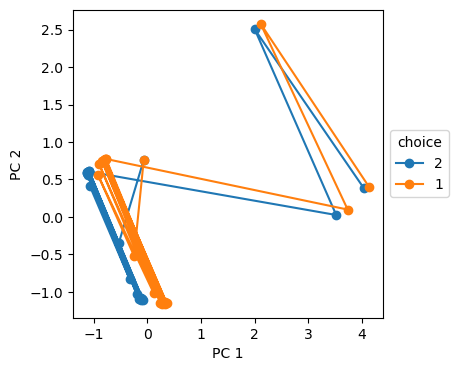

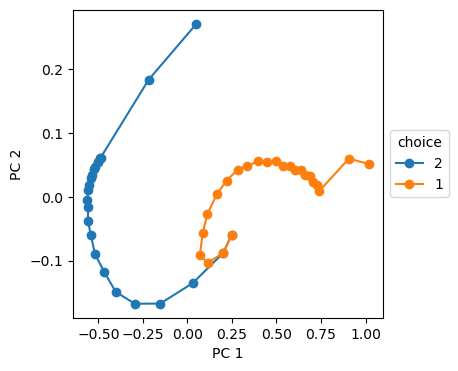

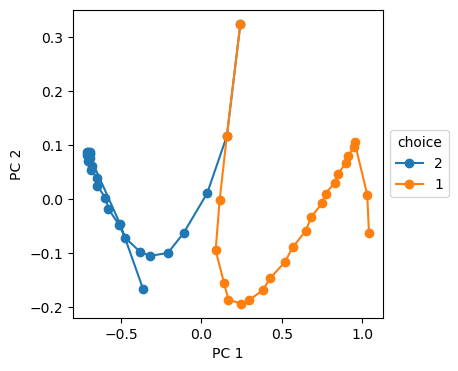

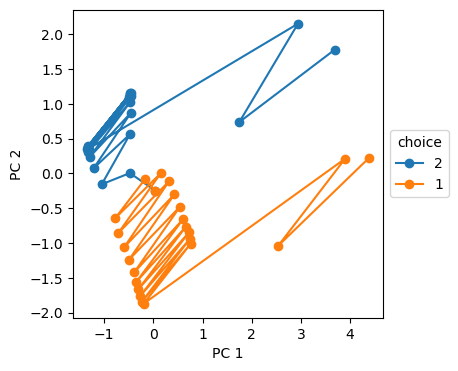

In [17]:
run_pca=True

plot_activity(hidden_activity, info, config, run_pca=run_pca, mask=masks['input_weight_mask'])
plot_activity(hidden_activity, info, config, run_pca=run_pca, mask=masks['bystanders'])
plot_activity(hidden_activity, info, config, run_pca=run_pca, mask=masks['output_weight_mask'])
plot_activity(hidden_activity, info, config, run_pca=run_pca)

Compute autocorrelation, tau

In [18]:
from src.utils import autocorr
from scipy.optimize import curve_fit

In [19]:
# The exponential decay function
def exp_decay(x, tau, init):
    return init*np.e**(-x/tau)

In [20]:
tau = np.zeros((n_trials, hidden_size))

for trial in tqdm(np.arange(n_trials)):
    for neuron in np.arange(hidden_size):
        try:
            t_ac, ac = autocorr(hidden_activity[trial, :, neuron], max_lag=trim)
            popt, pcov = curve_fit(exp_decay, t_ac, ac)
            fit_tau, fit_init = popt
            tau[trial, neuron] = fit_tau
        except:
            tau[trial, neuron] = np.nan

100%|██████████| 100/100 [00:01<00:00, 51.44it/s]


Plot outputs

In [21]:
file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-120-300_model-rnn-tanh-100-32-0.001-25-30000_wmask-True-14-27_reg-l2-0.002-euclidean


In [22]:
mask_labels = ['input_output', 'output_input',
               'input_bystanders', 'bystanders_input',
               'output_bystanders', 'bystanders_output']
n_masks = len(mask_labels)
mask_list = []
for i in np.arange(n_masks):
    mask_list.append(masks[mask_labels[i]])

0.08601


6it [00:02,  2.94it/s]


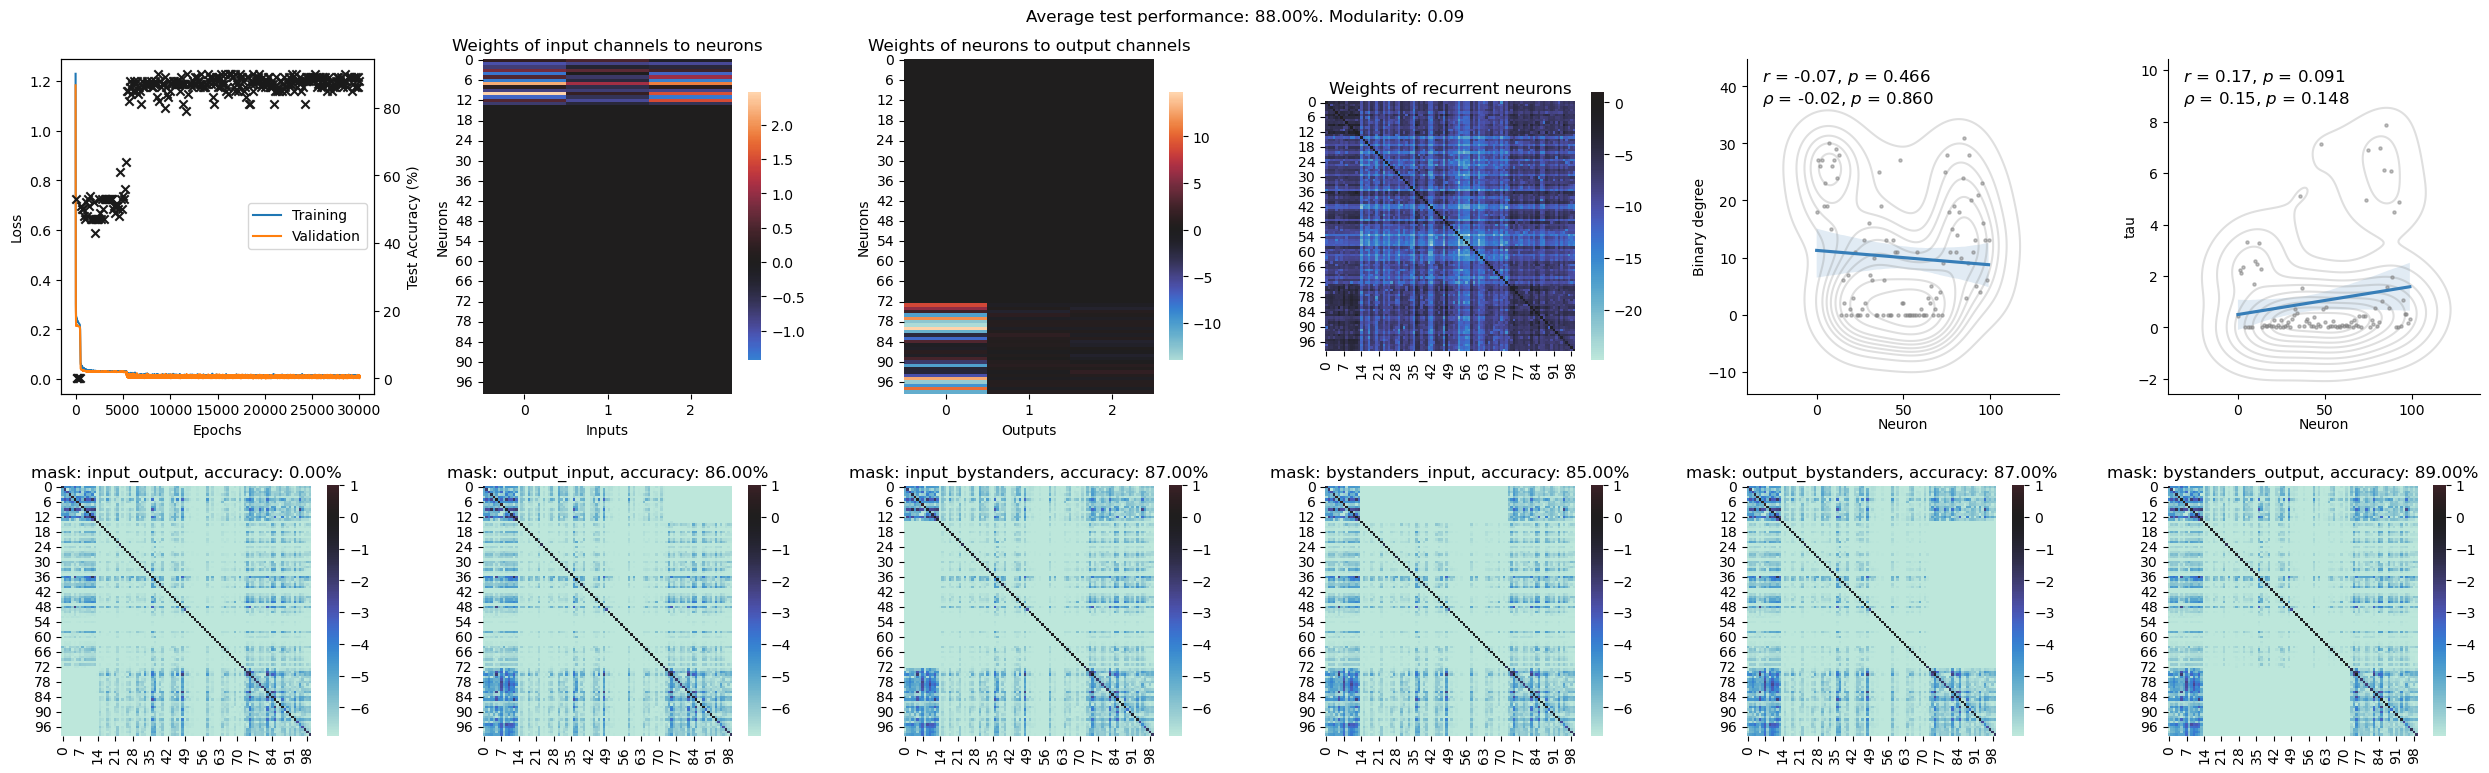

In [23]:
f, ax = plt.subplots(2, 6, figsize=(25, 8))

# performance
sns.lineplot(tra_loss, ax=ax[0, 0], label='Training')
sns.lineplot(val_loss, ax=ax[0, 0], label='Validation')
ax[0, 0].set_ylabel('Loss')
ax0_twin = ax[0, 0].twinx()
ax0_twin.scatter(np.arange(0, n_epochs+100, 100), tes_acc*100, marker='x', c='k')
ax0_twin.set_ylabel('Test Accuracy (%)')
ax[0, 0].set_xlabel('Epochs')
ax[0, 0].legend(loc='center right')

# input weights
sns.heatmap(model.rnn.weight_ih_l0.detach().cpu().numpy(), ax=ax[0, 1], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[0, 1].set_title('Weights of input channels to neurons')
ax[0, 1].set_xlabel('Inputs')
ax[0, 1].set_ylabel('Neurons')

# output weights
sns.heatmap(model.fc.weight.detach().cpu().numpy().T, ax=ax[0, 2], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[0, 2].set_title('Weights of neurons to output channels')
ax[0, 2].set_xlabel('Outputs')
ax[0, 2].set_ylabel('Neurons')

# hidden weights
h_weights = model.rnn.weight_hh_l0.detach().cpu().numpy()
if rnn_model == 'gru' or rnn_model == 'lstm':
    A = h_weights[:hidden_size, :].copy()
else:
    A = h_weights.copy()
thresh = np.quantile(A, q=0.9)
mask = A > thresh
A[mask] = 1
A[~mask] = 0
_, q_stat = bct.modularity_und(A, gamma=1)
print(q_stat)

sns.heatmap(np.log(np.abs(h_weights)), ax=ax[0, 3], square=True, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[0, 3].set_title('Weights of recurrent neurons')

# topology
my_reg_plot(np.arange(hidden_size), A.sum(axis=0), 'Neuron', 'Binary degree', ax[0, 4], fontsize=12, annotate='both')
my_reg_plot(np.arange(hidden_size), np.mean(tau, axis=0), 'Neuron', 'tau', ax=ax[0, 5], fontsize=12, annotate='both')

# second row, lesion analysis
lesioned_accuracy = pd.DataFrame(columns=mask_labels)

for j, mask in tqdm(enumerate(mask_list)):
    model_lesion = copy.deepcopy(model)
    with torch.no_grad():
        model_lesion.rnn.weight_hh_l0[mask] = 0
    lesioned_accuracy.loc[0, mask_labels[j]], _, _, _, _, _ = run_testing(dataset=dataset, model=model_lesion, n_trials=n_trials, verbose=False)

    h_weights_l = model_lesion.rnn.weight_hh_l0.detach().cpu().numpy()
    sns.heatmap(np.log(np.abs(h_weights_l)+0.001), ax=ax[1, j], square=True, center=0, cbar_kws={"shrink": 0.75})
    ax[1, j].set_title('mask: {:}, accuracy: {:.2f}%'.format(mask_labels[j], lesioned_accuracy.loc[0, mask_labels[j]] * 100))

f.suptitle('Average test performance: {:.2f}%. Modularity: {:.2f}'.format(accuracy*100, q_stat))

f.tight_layout()
plt.show()
f.savefig(os.path.join(outdir, '{0}_single-run.png'.format(file_str)), dpi=300, bbox_inches='tight', pad_inches=0.01)